# AAI614: Data Science & its Applications

*Notebook 7.2: Accelerating Data Science*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%207/Notebook7.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Source: Data Science with Python and Dask

### Examining the Metadata of Dask Objects

You would need for this lab to downlaod the data and store on your local disk as it is arond 2GB with 42.3M Rows of Parking Ticket Data.  The data can be downloaded from [Kaggle](http://www.kaggle.com/new-york-city/nyc-parking-tickets/)

In [65]:
import dask.dataframe as dd
from sklearn.datasets import load_iris
import pandas as pd

# load iris dataset
iris = load_iris()

# convert to pandas first
df_pd = pd.DataFrame(iris.data, columns=iris.feature_names)
df_pd["target"] = iris.target

# convert to dask dataframe
df = dd.from_pandas(df_pd, npartitions=1)

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
npartitions=1,,,,,
0,float64,float64,float64,float64,int64
149,...,...,...,...,...


In [66]:
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
petal length (cm)    int64
target                 ...
Dask Name: sum, 4 expressions
Expr=(~ NotNull(frame=df)).sum()

In [67]:
missing_count = ((missing_values / df.index.size) * 100)
missing_count

Dask Series Structure:
npartitions=1
petal length (cm)    float64
target                   ...
Dask Name: mul, 8 expressions
Expr=(~ NotNull(frame=df)).sum() / Index(frame=df).size() * 100

### Running Computations with the Compute Method

In [68]:
with ProgressBar():
    missing_count_pct = missing_count.compute()
missing_count_pct

[########################################] | 100% Completed | 102.44 ms


,0
sepal length (cm),0.0
sepal width (cm),0.0
petal length (cm),0.0
petal width (cm),0.0
target,0.0


In [69]:
from dask.diagnostics import ProgressBar

columns_to_drop = missing_count_pct[missing_count_pct > 60].index.tolist()

with ProgressBar():
    df_dropped = df.drop(columns=columns_to_drop).persist()

[########################################] | 100% Completed | 102.09 ms


### Visualizing a Simple DAG using Dask Delayed Objects

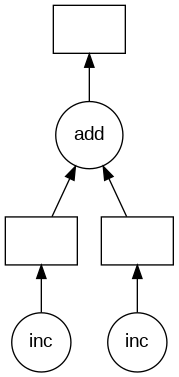

In [70]:
import dask.delayed as delayed
from dask.diagnostics import ProgressBar

def inc(i):
    return i + 1

def add(x, y):
    return x + y

x = delayed(inc)(1)
y = delayed(inc)(2)
z = delayed(add)(x, y)

z.visualize()

### Visualizing More Complex DAGs with Loops and Collections

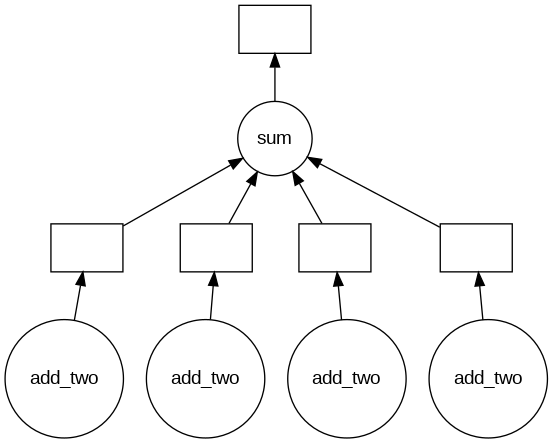

In [71]:
# Listing 2.7
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
total = delayed(sum)(step1)
total.visualize()

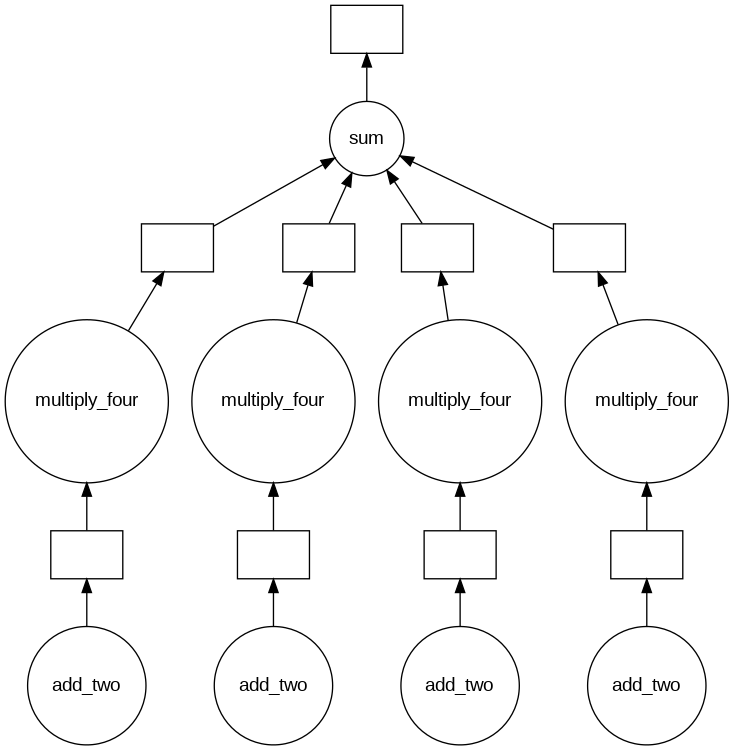

In [72]:
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
step2 = [delayed(multiply_four)(j) for j in step1]
total = delayed(sum)(step2)
total.visualize()

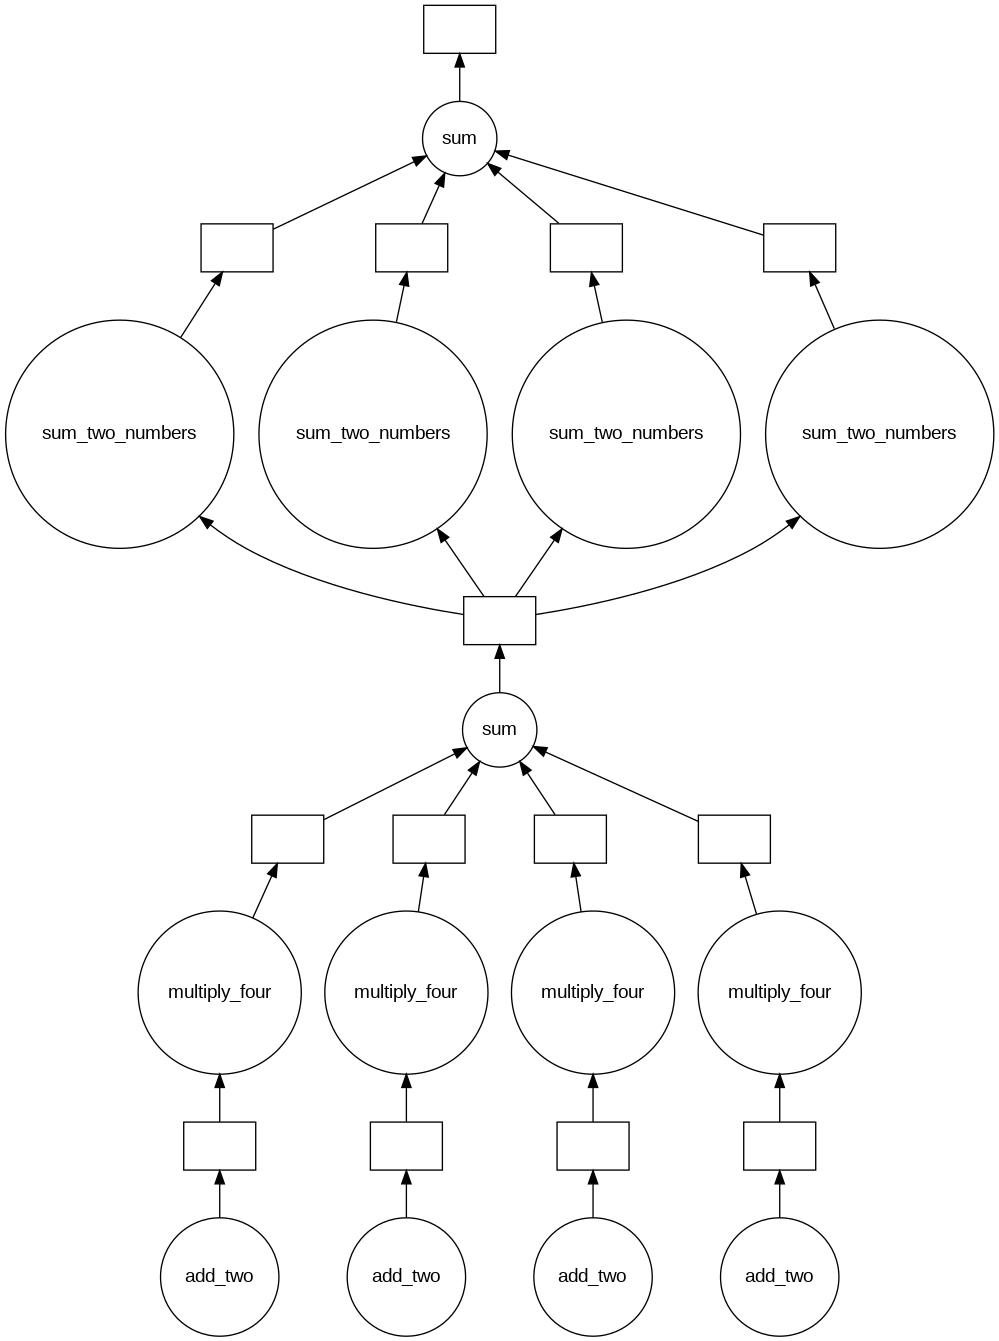

In [73]:
data2 = [delayed(sum_two_numbers)(k, total) for k in data]
total2 = delayed(sum)(data2)
total2.visualize()

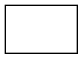

In [74]:
total_persisted = total.persist()
total_persisted.visualize()

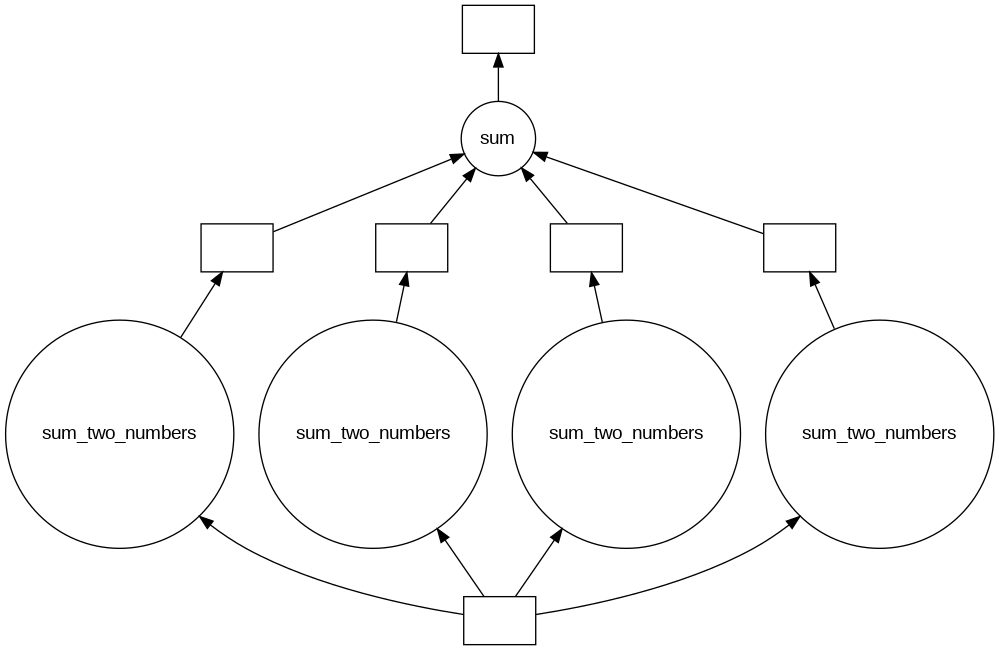

In [75]:
data2 = [delayed(sum_two_numbers)(l, total_persisted) for l in data]
total2 = delayed(sum)(data2)
total2.visualize()

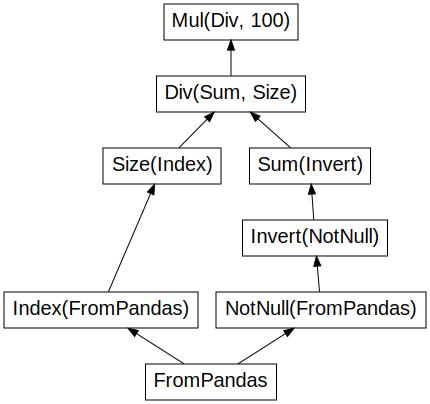

In [76]:
missing_count.visualize()